In [1]:
import pandas as pd

def read_csv_to_dataframe(file_path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return pd.DataFrame()

In [2]:
Rosedata_df = read_csv_to_dataframe("Event_core_v4.csv")
print(Rosedata_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_date                    29 non-null     object 
 1   event_id                      29 non-null     object 
 2   parent_event_id               46 non-null     object 
 3   type                          46 non-null     object 
 4   location_id                   46 non-null     object 
 5   decimal_latitud               29 non-null     float64
 6   decimal_longitude             29 non-null     float64
 7   depth_m                       46 non-null     int64  
 8   habitat                       46 non-null     object 
 9   conteo_ind                    46 non-null     int64  
 10  temperat_grad_c               46 non-null     float64
 11  total_organic_matter_percent  46 non-null     float64
 12  proport_silt_clay_percent     46 non-null     int64  
 13  prop_si

* Regresión lineal simple temperatura vs. materia orgánica total:

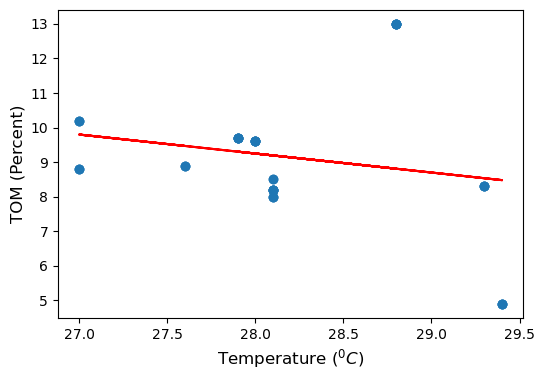

Slope: -0.5493660052282467


In [3]:
import matplotlib.pyplot as plt
from scipy import stats

x = Rosedata_df['temperat_grad_c']
y = Rosedata_df['total_organic_matter_percent']

plt.scatter(x, y, label='original data')

# Add labels and title
plt.xlabel('Temperature ($^{0}C$)', fontsize = 12, )
plt.ylabel('TOM (Percent)', fontsize = 12)

# Calculate the linear regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Plot linear regression 

plt.plot(x, intercept + slope*x, 'r', label='fitted line')

# set the figure size
plt.gcf().set_size_inches(6, 4)

# save the plot as a PDF file paper format 
import os
output_dir = '../output_files'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'Tem_TOM.pdf'), dpi=300, bbox_inches='tight')


plt.show()

print('Slope:', slope)

In [4]:
print("r-squared:", r_value**2)
print("p_value:", p_value)
print("slope:", slope)
print("intercept:", intercept)

r-squared: 0.038923155664908504
p_value: 0.188772807895369
slope: -0.5493660052282467
intercept: 24.629842873489423


* Regresión lineal OLS:

In [5]:
import statsmodels.api as sm
import numpy as np

# Define the independent and dependent variables
x = Rosedata_df['temperat_grad_c']
y = Rosedata_df['total_organic_matter_percent']

# Add a constant to include the intercept in the model
# This step is necessary; otherwise, the regression will be forced through the origin (intercept = 0)
x = sm.add_constant(x)

# Fit the Ordinary Least Squares (OLS) linear regression model
model = sm.OLS(y, x).fit()

# Display the model summary
print(model.summary())

                                 OLS Regression Results                                 
Dep. Variable:     total_organic_matter_percent   R-squared:                       0.039
Model:                                      OLS   Adj. R-squared:                  0.017
Method:                           Least Squares   F-statistic:                     1.782
Date:                          Sat, 30 Aug 2025   Prob (F-statistic):              0.189
Time:                                  22:33:53   Log-Likelihood:                -95.889
No. Observations:                            46   AIC:                             195.8
Df Residuals:                                44   BIC:                             199.4
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

In [8]:
print("\n=== MODEL INTERPRETATION ===\n")

# R-squared and fit quality
r2 = model.rsquared
fit_quality = (
    "✔️ Good model fit: Explains most of the variance." if r2 >= 0.7 else
    "⚠️ Moderate model fit: Explains part of the variance." if r2 >= 0.4 else
    "❌ Weak model fit: Explains little variance. Review your model."
)
print(f"R² = {r2:.3f}\n{fit_quality}")

# Coefficients and p-values
results = model.summary2().tables[1]
slope_var = results.index.drop('const')[0]  # Assuming one predictor

print("\nCoefficients:")
for var, row in results.iterrows():
    coef, pval = row['Coef.'], row['P>|t|']
    significance = "✔️ Significant (p < 0.05)" if pval < 0.05 else "⚠️ Not significant (p ≥ 0.05)"
    print(f"- {var}: Coef = {coef:.4f}, p = {pval:.4f} → {significance}")

# Slope interpretation
slope_coef, slope_pval = results.loc[slope_var, ['Coef.', 'P>|t|']]
print(f"\nSlope ({slope_var}): {slope_coef:.4f}, p = {slope_pval:.4f} → "
      f"{'✔️ Significant' if slope_pval < 0.05 else '⚠️ Not significant'}")

# Standard Error
print(f"\nStandard Error of the model: {np.sqrt(model.scale):.4f}")


=== MODEL INTERPRETATION ===

R² = 0.039
❌ Weak model fit: Explains little variance. Review your model.

Coefficients:
- const: Coef = 24.6298, p = 0.0395 → ✔️ Significant (p < 0.05)
- temperat_grad_c: Coef = -0.5494, p = 0.1888 → ⚠️ Not significant (p ≥ 0.05)

Slope (temperat_grad_c): -0.5494, p = 0.1888 → ⚠️ Not significant

Standard Error of the model: 1.9894


* Regresión lineal simple temperatura vs. profundidad:

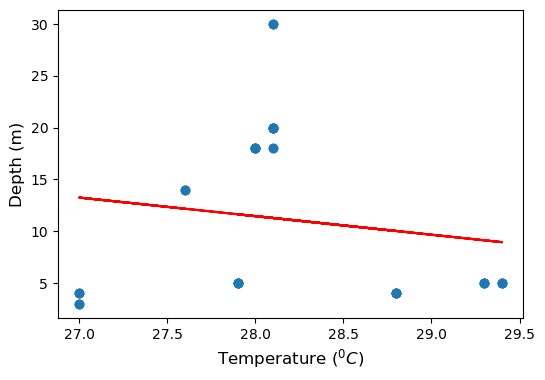

Slope: -1.791651549403208


In [6]:
import matplotlib.pyplot as plt
from scipy import stats

x = Rosedata_df['temperat_grad_c']
y = Rosedata_df['depth_m']

plt.scatter(x, y, label='original data')

# Add labels and title
plt.xlabel('Temperature ($^{0}C$)', fontsize = 12, )
plt.ylabel('Depth (m)', fontsize = 12)

# Calculate the linear regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Plot linear regression 

plt.plot(x, intercept + slope*x, 'r', label='fitted line')

# set the figure size
plt.gcf().set_size_inches(6, 4)

# save the plot as a PDF file paper format 
import os
output_dir = '../output_files'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'Tem_Depth.pdf'), dpi=300, bbox_inches='tight')


plt.show()

print('Slope:', slope)

In [7]:
print("r-squared:", r_value**2)
print("p_value:", p_value)
print("slope:", slope)
print("intercept:", intercept)

r-squared: 0.02400794377453901
p_value: 0.3038591094416494
slope: -1.791651549403208
intercept: 61.621584661326544


* Regresión lineal OLS tempe vs. profund:

In [9]:
import statsmodels.api as sm
import numpy as np

# Define the independent and dependent variables
x = Rosedata_df['temperat_grad_c']
y = Rosedata_df['depth_m']

# Add a constant to include the intercept in the model
# This step is necessary; otherwise, the regression will be forced through the origin (intercept = 0)
x = sm.add_constant(x)

# Fit the Ordinary Least Squares (OLS) linear regression model
model = sm.OLS(y, x).fit()

# Display the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                depth_m   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.082
Date:                Sat, 30 Aug 2025   Prob (F-statistic):              0.304
Time:                        22:36:27   Log-Likelihood:                -161.73
No. Observations:                  46   AIC:                             327.5
Df Residuals:                      44   BIC:                             331.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              61.6216     48.569     

In [10]:
print("\n=== MODEL INTERPRETATION ===\n")

# R-squared and fit quality
r2 = model.rsquared
fit_quality = (
    "✔️ Good model fit: Explains most of the variance." if r2 >= 0.7 else
    "⚠️ Moderate model fit: Explains part of the variance." if r2 >= 0.4 else
    "❌ Weak model fit: Explains little variance. Review your model."
)
print(f"R² = {r2:.3f}\n{fit_quality}")

# Coefficients and p-values
results = model.summary2().tables[1]
slope_var = results.index.drop('const')[0]  # Assuming one predictor

print("\nCoefficients:")
for var, row in results.iterrows():
    coef, pval = row['Coef.'], row['P>|t|']
    significance = "✔️ Significant (p < 0.05)" if pval < 0.05 else "⚠️ Not significant (p ≥ 0.05)"
    print(f"- {var}: Coef = {coef:.4f}, p = {pval:.4f} → {significance}")

# Slope interpretation
slope_coef, slope_pval = results.loc[slope_var, ['Coef.', 'P>|t|']]
print(f"\nSlope ({slope_var}): {slope_coef:.4f}, p = {slope_pval:.4f} → "
      f"{'✔️ Significant' if slope_pval < 0.05 else '⚠️ Not significant'}")

# Standard Error
print(f"\nStandard Error of the model: {np.sqrt(model.scale):.4f}")


=== MODEL INTERPRETATION ===

R² = 0.024
❌ Weak model fit: Explains little variance. Review your model.

Coefficients:
- const: Coef = 61.6216, p = 0.2112 → ⚠️ Not significant (p ≥ 0.05)
- temperat_grad_c: Coef = -1.7917, p = 0.3039 → ⚠️ Not significant (p ≥ 0.05)

Slope (temperat_grad_c): -1.7917, p = 0.3039 → ⚠️ Not significant

Standard Error of the model: 8.3250
